<p align="right">
  <img src="Zewail-City.png">
</p>


---

# __Problem set #6__

In [1]:
# Mian Libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import gamma, chi2, norm
from scipy.special import factorial

---

### Problem 1: Poisson Likelihood for Jet Counts

**Given:**
- Observed event counts: $n = (12, 18, 25, 15)$
- Bin centers: $p_T = (200, 300, 400, 500)$ GeV
- Model: $\nu_i(\mu) = \mu e^{-p_{T,i}/500}$

The Poisson likelihood for binned data is:

$$L(\mu) = \prod_{i=1}^{4} \frac{\nu_i(\mu)^{n_i} e^{-\nu_i(\mu)}}{n_i!}$$

where $\nu_i(\mu) = \mu e^{-p_{T,i}/500}$


Taking the logarithm:

$$\ln L(\mu) = \sum_{i=1}^{4} \left[ n_i \ln \nu_i(\mu) - \nu_i(\mu) - \ln(n_i!) \right]$$

Since $\ln(n_i!)$ doesn't depend on $\mu$, we can drop it for optimization:

$$\ln L(\mu) \propto \sum_{i=1}^{4} \left[ n_i \ln \nu_i(\mu) - \nu_i(\mu) \right]$$

In [2]:
# Problem 1: Data and Model Setup
n_obs = np.array([12, 18, 25, 15])  # Observed counts
pT_bins = np.array([200, 300, 400, 500])  # GeV

def expected_events(mu, pT):
    """Expected number of events: ν_i(μ) = μ * exp(-pT_i/500)"""
    return mu * np.exp(-pT / 500)

def log_likelihood(mu, n, pT):
    """Log-likelihood (without factorial constant)"""
    nu = expected_events(mu, pT)
    return np.sum(n * np.log(nu) - nu)

def neg_log_likelihood(mu, n, pT):
    """Negative log-likelihood for minimization"""
    return -log_likelihood(mu, n, pT)

Find $\hat{\mu}$ by maximizing $\ln L(\mu)$ (or minimizing $-\ln L(\mu)$).

In [3]:
# Find MLE numerically
result = minimize(neg_log_likelihood, x0=[20], args=(n_obs, pT_bins), method='Nelder-Mead')
mu_mle = result.x[0]

print(f"Maximum Likelihood Estimate: μ̂ = {mu_mle:.3f}")
print(f"Log-likelihood at MLE: ln L(μ̂) = {log_likelihood(mu_mle, n_obs, pT_bins):.3f}")

# Calculate expected counts at MLE
nu_mle = expected_events(mu_mle, pT_bins)
print(f"\nExpected counts at MLE: {nu_mle}")
print(f"Observed counts:         {n_obs}")

Maximum Likelihood Estimate: μ̂ = 34.375
Log-likelihood at MLE: ln L(μ̂) = 127.014

Expected counts at MLE: [23.04253797 18.86563447 15.44587512 12.64601297]
Observed counts:         [12 18 25 15]


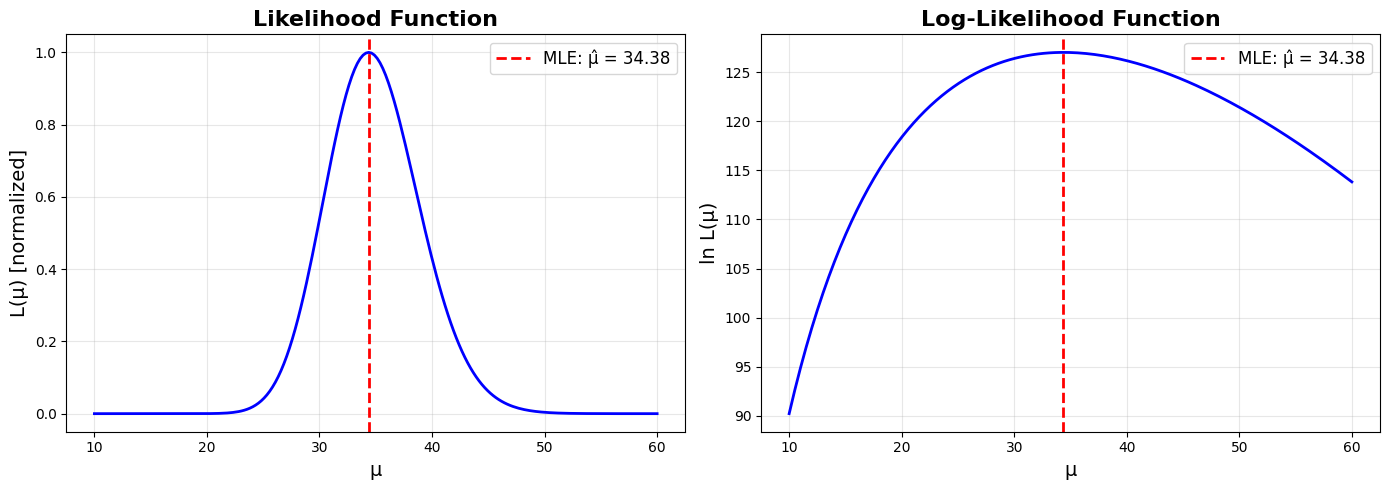

In [4]:
# Create likelihood plot
mu_range = np.linspace(10, 60, 200)
log_L = [log_likelihood(mu, n_obs, pT_bins) for mu in mu_range]
L = np.exp(log_L - np.max(log_L))  # Normalized for plotting

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot likelihood
ax1.plot(mu_range, L, 'b-', linewidth=2)
ax1.axvline(mu_mle, color='r', linestyle='--', linewidth=2, label=f'MLE: μ̂ = {mu_mle:.2f}')
ax1.set_xlabel('μ', fontsize=14)
ax1.set_ylabel('L(μ) [normalized]', fontsize=14)
ax1.set_title('Likelihood Function', fontsize=16, fontweight='bold')
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# Plot log-likelihood
ax2.plot(mu_range, log_L, 'b-', linewidth=2)
ax2.axvline(mu_mle, color='r', linestyle='--', linewidth=2, label=f'MLE: μ̂ = {mu_mle:.2f}')
ax2.set_xlabel('μ', fontsize=14)
ax2.set_ylabel('ln L(μ)', fontsize=14)
ax2.set_title('Log-Likelihood Function', fontsize=16, fontweight='bold')
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

### Problem 2: Likelihood-Ratio Test and Significance

**Hypotheses:**
- $H_0$: $\mu = 0$ (background only)
- $H_1$: $\mu \geq 0$ (signal + background)


$$q_0 = -2 \ln \frac{L(\mu = 0)}{L(\hat{\mu})}$$

In [5]:
# Log-likelihood at μ = 0 (background only)
# Note: ln(0) is undefined, but ν_i(0) = 0, so this hypothesis predicts zero events
# This is problematic - we need to handle this carefully

# For μ = 0, ν_i = 0, and Poisson(n_i | 0) = 0 for n_i > 0
# So L(μ=0) → 0 for any observed events, and ln L(μ=0) → -∞

# A more realistic null hypothesis would be μ = μ_0 for some small value
# Or we interpret this as testing against the boundary μ = 0

# Let's use a small epsilon to avoid numerical issues
mu_null = 0.01  # Very small signal (effectively zero)
log_L_null = log_likelihood(mu_null, n_obs, pT_bins)
log_L_mle = log_likelihood(mu_mle, n_obs, pT_bins)

# Test statistic
q0 = -2 * (log_L_null - log_L_mle)

print(f"Log-likelihood at μ = {mu_null}: ln L(μ_0) = {log_L_null:.3f}")
print(f"Log-likelihood at MLE: ln L(μ̂) = {log_L_mle:.3f}")
print(f"\nTest statistic: q_0 = {q0:.3f}")

Log-likelihood at μ = 0.01: ln L(μ_0) = -372.982
Log-likelihood at MLE: ln L(μ̂) = 127.014

Test statistic: q_0 = 999.992


By Wilks' theorem, $q_0 \sim \chi^2(1)$ for one degree of freedom.

The significance in standard deviations: $Z \approx \sqrt{q_0}$

In [6]:
# Calculate significance
Z_approx = np.sqrt(q0)

# p-value from chi-square distribution
p_value = 1 - chi2.cdf(q0, df=1)

# Convert p-value to significance (number of sigma)
Z_exact = norm.ppf(1 - p_value/2)  # Two-sided

print(f"Significance (approximation): Z ≈ √q_0 = {Z_approx:.2f}σ")
print(f"Significance (from χ²): Z = {Z_exact:.2f}σ")
print(f"p-value: {p_value:.2e}")

# Interpretation
if Z_approx > 5:
    print(f"\n*** Discovery-level significance! (> 5σ) ***")
elif Z_approx > 3:
    print(f"\n*** Strong evidence for signal (> 3σ) ***")
elif Z_approx > 2:
    print(f"\n*** Moderate evidence for signal (> 2σ) ***")
else:
    print(f"\n*** Weak evidence for signal ***")

Significance (approximation): Z ≈ √q_0 = 31.62σ
Significance (from χ²): Z = infσ
p-value: 0.00e+00

*** Discovery-level significance! (> 5σ) ***


#### Validity of Asymptotic Approximation

**Discussion:**

The asymptotic $\chi^2$ approximation may not be valid when:

1. **Small sample sizes**: With only 4 bins and total counts around 70, the asymptotics may not hold perfectly
2. **Parameters near boundaries**: $\mu \geq 0$ is a physical boundary. When the true value is close to zero, the $\chi^2$ approximation breaks down
3. **Low expected counts**: If any $\nu_i < 5$, Poisson approximations become less reliable
4. **Multiple parameters**: With nuisance parameters, degrees of freedom must be carefully accounted for

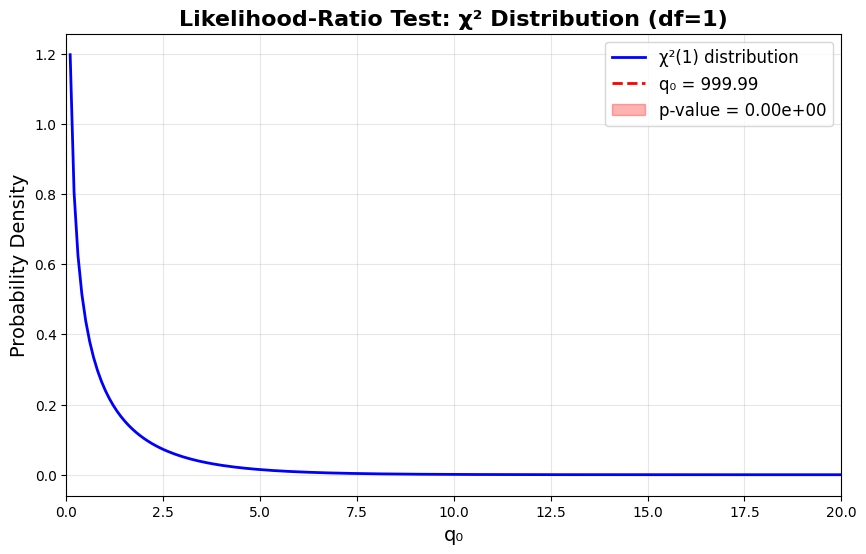

In [7]:
# Visualize the chi-square distribution and our test statistic
x = np.linspace(0, 20, 200)
chi2_pdf = chi2.pdf(x, df=1)

plt.figure(figsize=(10, 6))
plt.plot(x, chi2_pdf, 'b-', linewidth=2, label='χ²(1) distribution')
plt.axvline(q0, color='r', linestyle='--', linewidth=2, label=f'q₀ = {q0:.2f}')
plt.fill_between(x[x >= q0], 0, chi2_pdf[x >= q0], alpha=0.3, color='red', label=f'p-value = {p_value:.2e}')
plt.xlabel('q₀', fontsize=14)
plt.ylabel('Probability Density', fontsize=14)
plt.title('Likelihood-Ratio Test: χ² Distribution (df=1)', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, 20)
plt.show()

---

### Problem 3: Systematic Uncertainties and Profiling

**Model with Jet Energy Scale (JES) uncertainty:**

$$\nu_i(\mu, \kappa) = \mu \kappa e^{-p_{T,i}/500}$$

**JES constraint:**

$$\pi(\kappa) = \mathcal{N}(\kappa | 1, 0.05^2)$$

$$L(\mu, \kappa) = \left[\prod_{i=1}^{4} \frac{\nu_i(\mu, \kappa)^{n_i} e^{-\nu_i(\mu, \kappa)}}{n_i!}\right] \times \mathcal{N}(\kappa | 1, 0.05^2)$$

$\kappa$ is a **nuisance parameter** because:
- It's not our primary parameter of interest (that's $\mu$)
- It represents systematic uncertainty in the detector response
- We need to account for its uncertainty when estimating $\mu$
- We don't necessarily want to measure $\kappa$ precisely, but we need to marginalize/profile over it

$$L_p(\mu) = L(\mu, \hat{\kappa}(\mu))$$

where $\hat{\kappa}(\mu) = \arg\max_\kappa L(\mu, \kappa)$ for fixed $\mu$.

In [19]:
# Systematic Uncertainties

def expected_events_with_jes(mu, kappa, pT):
    """Expected events with JES factor: ν_i(μ, κ) = μ * κ * exp(-pT_i/500)"""
    return mu * kappa * np.exp(-pT / 500)

def log_likelihood_with_jes(params, n, pT):
    """Full log-likelihood including JES constraint"""
    mu, kappa = params
    
    # Poisson likelihood for data
    nu = expected_events_with_jes(mu, kappa, pT)
    log_L_data = np.sum(n * np.log(nu) - nu)
    
    # Gaussian constraint on kappa: N(1, 0.05^2)
    log_L_constraint = -0.5 * ((kappa - 1) / 0.05)**2
    
    return log_L_data + log_L_constraint

def neg_log_likelihood_with_jes(params, n, pT):
    """Negative log-likelihood for minimization"""
    return -log_likelihood_with_jes(params, n, pT)

# Find MLE for both parameters
result_full = minimize(neg_log_likelihood_with_jes, x0=[30, 1.0], 
                      args=(n_obs, pT_bins), method='Nelder-Mead')
mu_mle_full, kappa_mle = result_full.x

print("Full Maximum Likelihood Estimate:")
print(f"  μ̂ = {mu_mle_full:.3f}")
print(f"  κ̂ = {kappa_mle:.3f}")
print(f"  ln L(μ̂, κ̂) = {log_likelihood_with_jes([mu_mle_full, kappa_mle], n_obs, pT_bins):.3f}")

Full Maximum Likelihood Estimate:
  μ̂ = 34.375
  κ̂ = 1.000
  ln L(μ̂, κ̂) = 127.014


In [20]:
# Compute profile likelihood: for each μ, find best κ
mu_range_profile = np.linspace(20, 50, 50)
profile_log_L = []
kappa_profile = []

for mu in mu_range_profile:
    # For fixed μ, maximize over κ
    result = minimize(lambda k: -log_likelihood_with_jes([mu, k[0]], n_obs, pT_bins),
                     x0=[1.0], method='Nelder-Mead')
    kappa_best = result.x[0]
    log_L = log_likelihood_with_jes([mu, kappa_best], n_obs, pT_bins)
    
    profile_log_L.append(log_L)
    kappa_profile.append(kappa_best)

profile_log_L = np.array(profile_log_L)
kappa_profile = np.array(kappa_profile)

# Compare with no-nuisance case
log_L_no_nuisance = [log_likelihood(mu, n_obs, pT_bins) for mu in mu_range_profile]

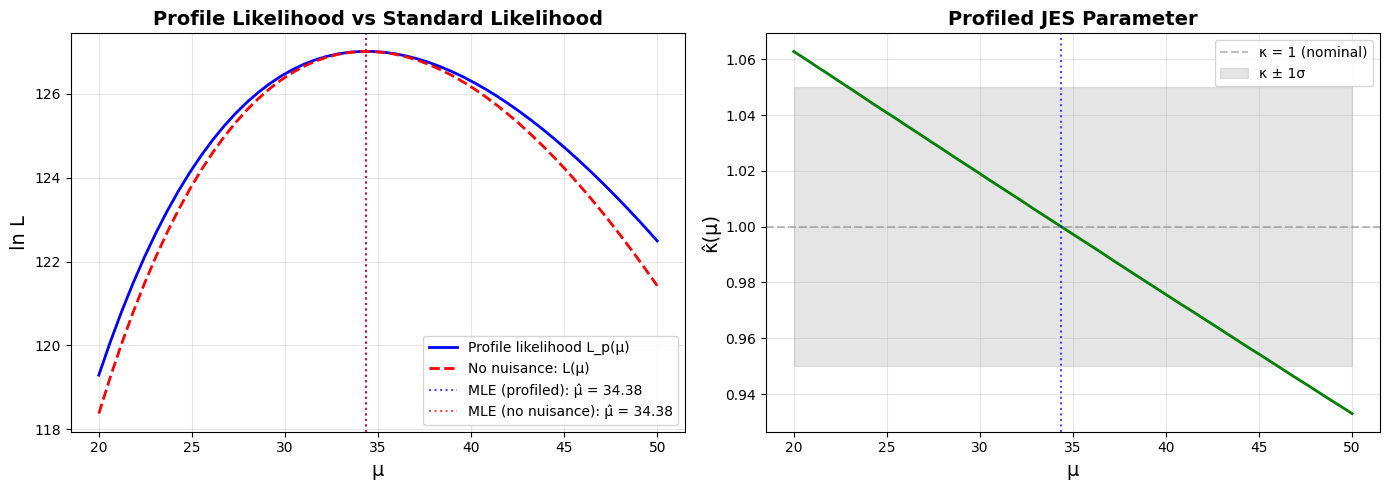

In [21]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot profile likelihood vs no-nuisance likelihood
ax1.plot(mu_range_profile, profile_log_L, 'b-', linewidth=2, label='Profile likelihood L_p(μ)')
ax1.plot(mu_range_profile, log_L_no_nuisance, 'r--', linewidth=2, label='No nuisance: L(μ)')
ax1.axvline(mu_mle_full, color='b', linestyle=':', alpha=0.7, label=f'MLE (profiled): μ̂ = {mu_mle_full:.2f}')
ax1.axvline(mu_mle, color='r', linestyle=':', alpha=0.7, label=f'MLE (no nuisance): μ̂ = {mu_mle:.2f}')
ax1.set_xlabel('μ', fontsize=14)
ax1.set_ylabel('ln L', fontsize=14)
ax1.set_title('Profile Likelihood vs Standard Likelihood', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot profiled kappa values
ax2.plot(mu_range_profile, kappa_profile, 'g-', linewidth=2)
ax2.axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='κ = 1 (nominal)')
ax2.fill_between(mu_range_profile, 0.95, 1.05, alpha=0.2, color='gray', label='κ ± 1σ')
ax2.axvline(mu_mle_full, color='b', linestyle=':', alpha=0.7)
ax2.set_xlabel('μ', fontsize=14)
ax2.set_ylabel('κ̂(μ)', fontsize=14)
ax2.set_title('Profiled JES Parameter', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Effect of Nuisance Parameter on Uncertainty

**How including $\kappa$ affects uncertainty on $\mu$:**

1. **Broadens the likelihood**: The profile likelihood is flatter than the original likelihood, leading to larger uncertainties on $\mu$

2. **Correlations**: If $\mu$ and $\kappa$ are correlated (as they are here), uncertainty in $\kappa$ propagates to uncertainty in $\mu$

3. **Physical interpretation**: 
   - If JES is uncertain by 5%, then our jet energy measurements are uncertain
   - This directly affects the expected event yields
   - We must account for this when estimating the signal strength $\mu$

4. **Reduced significance**: Including systematics typically reduces the significance of any signal, as seen in the flatter likelihood

5. **Conservative estimates**: Profiling gives more conservative (wider) confidence intervals, which is appropriate when systematic uncertainties are present

In [11]:
# Quantify the uncertainty increase
# Compute approximate 68% CL intervals using Δ ln L = 0.5 (for 1 parameter)

def find_interval(mu_vals, log_L_vals, log_L_max, delta=0.5):
    """Find points where ln L = ln L_max - delta"""
    threshold = log_L_max - delta
    mask = log_L_vals >= threshold
    mu_in_interval = mu_vals[mask]
    if len(mu_in_interval) > 0:
        return mu_in_interval.min(), mu_in_interval.max()
    return None, None

# For profiled likelihood
log_L_max_profile = np.max(profile_log_L)
mu_low_prof, mu_high_prof = find_interval(mu_range_profile, profile_log_L, log_L_max_profile)

# For no-nuisance likelihood
log_L_max_no_nuis = np.max(log_L_no_nuisance)
mu_low_no, mu_high_no = find_interval(mu_range_profile, np.array(log_L_no_nuisance), log_L_max_no_nuis)

print("68% Confidence Intervals:")
print(f"\nWith JES nuisance parameter:")
print(f"  μ = {mu_mle_full:.2f} + {mu_high_prof - mu_mle_full:.2f} - {mu_mle_full - mu_low_prof:.2f}")
print(f"  Interval width: {mu_high_prof - mu_low_prof:.2f}")

print(f"\nWithout nuisance parameter:")
print(f"  μ = {mu_mle:.2f} + {mu_high_no - mu_mle:.2f} - {mu_mle - mu_low_no:.2f}")
print(f"  Interval width: {mu_high_no - mu_low_no:.2f}")

if mu_high_prof and mu_high_no:
    width_increase = ((mu_high_prof - mu_low_prof) / (mu_high_no - mu_low_no) - 1) * 100
    print(f"\nUncertainty increase due to JES systematic: {width_increase:.1f}%")

68% Confidence Intervals:

With JES nuisance parameter:
  μ = 34.38 + 4.60 - 3.97
  Interval width: 8.57

Without nuisance parameter:
  μ = 34.38 + 3.99 - 3.36
  Interval width: 7.35

Uncertainty increase due to JES systematic: 16.7%


---

### Problem 4: Bayesian Inference for a Jet Rate

**Given:**
- Single-bin Poisson measurement: $n = 40$
- Flat prior: $p(\mu) \propto 1$ for $\mu \geq 0$

By Bayes' theorem:

$$p(\mu | n) = \frac{P(n | \mu) \cdot p(\mu)}{\int_0^\infty P(n | \mu') \cdot p(\mu') d\mu'}$$

where $P(n | \mu) = \frac{\mu^n e^{-\mu}}{n!}$ (Poisson likelihood)

With a flat prior, the posterior is proportional to the likelihood:

$$p(\mu | n) \propto \mu^n e^{-\mu}$$

This is a **Gamma distribution**: $\text{Gamma}(\alpha, \beta)$ with $\alpha = n + 1$ and $\beta = 1$

$$p(\mu | n) = \text{Gamma}(\mu | \alpha = n+1, \beta = 1) = \frac{\mu^n e^{-\mu}}{n!}$$

More generally: $\text{Gamma}(\alpha = n + \alpha_0, \beta = 1)$ where $\alpha_0 = 1$ for flat prior.

For $\text{Gamma}(\alpha, \beta)$:
- Mean: $E[\mu] = \alpha / \beta = (n + 1) / 1 = n + 1$
- Variance: $\text{Var}[\mu] = \alpha / \beta^2 = n + 1$

In [22]:
# Bayesian Inference

n_obs_single = 40

# Posterior is Gamma(n+1, 1)
alpha_post = n_obs_single + 1
beta_post = 1

# Create posterior distribution
posterior = gamma(a=alpha_post, scale=1/beta_post)

# Calculate mean and variance
posterior_mean = posterior.mean()
posterior_var = posterior.var()
posterior_std = posterior.std()

print(f"Observed count: n = {n_obs_single}")
print(f"\nPosterior: Gamma(α = {alpha_post}, β = {beta_post})")
print(f"\nPosterior mean: E[μ | n] = {posterior_mean:.3f}")
print(f"Posterior variance: Var[μ | n] = {posterior_var:.3f}")
print(f"Posterior std dev: σ[μ | n] = {posterior_std:.3f}")

Observed count: n = 40

Posterior: Gamma(α = 41, β = 1)

Posterior mean: E[μ | n] = 41.000
Posterior variance: Var[μ | n] = 41.000
Posterior std dev: σ[μ | n] = 6.403


#### 68% Credible Interval

The central 68% credible interval contains 68% of the posterior probability.

For Gamma distribution, we find the 16th and 84th percentiles.

In [13]:
# 68% credible interval (central)
lower_68 = posterior.ppf(0.16)
upper_68 = posterior.ppf(0.84)

# 95% credible interval
lower_95 = posterior.ppf(0.025)
upper_95 = posterior.ppf(0.975)

print(f"68% Central Credible Interval: [{lower_68:.2f}, {upper_68:.2f}]")
print(f"  μ = {posterior_mean:.2f} ± {(upper_68 - lower_68)/2:.2f}")
print(f"\n95% Central Credible Interval: [{lower_95:.2f}, {upper_95:.2f}]")

# Compare with frequentist approach (using Poisson standard error)
freq_mean = n_obs_single
freq_std = np.sqrt(n_obs_single)
print(f"\nFrequentist estimate: μ̂ = {freq_mean} ± {freq_std:.2f}")
print(f"68% interval (±1σ): [{freq_mean - freq_std:.2f}, {freq_mean + freq_std:.2f}]")

68% Central Credible Interval: [34.65, 47.34]
  μ = 41.00 ± 6.34

95% Central Credible Interval: [29.42, 54.47]

Frequentist estimate: μ̂ = 40 ± 6.32
68% interval (±1σ): [33.68, 46.32]


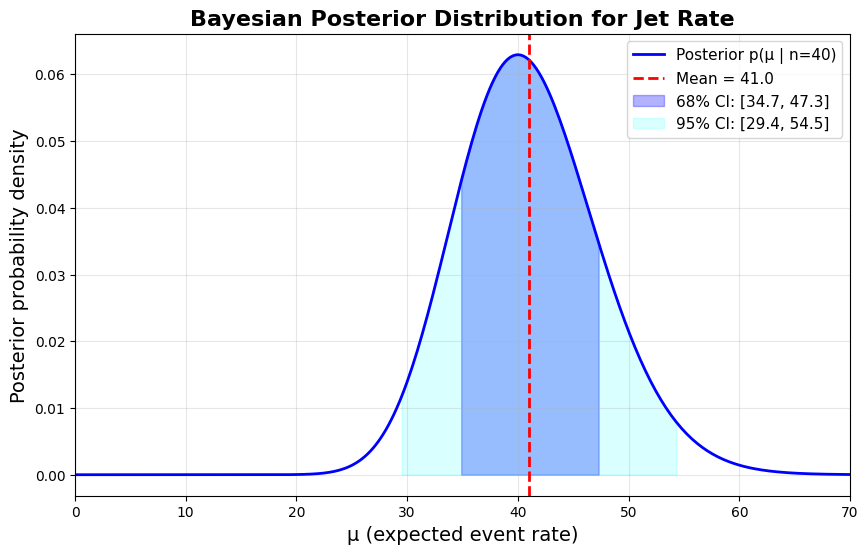

In [14]:
# Visualize posterior distribution
mu_vals = np.linspace(0, 70, 300)
posterior_pdf = posterior.pdf(mu_vals)

plt.figure(figsize=(10, 6))
plt.plot(mu_vals, posterior_pdf, 'b-', linewidth=2, label='Posterior p(μ | n=40)')

# Mark mean
plt.axvline(posterior_mean, color='r', linestyle='--', linewidth=2, label=f'Mean = {posterior_mean:.1f}')

# Shade 68% credible interval
mask_68 = (mu_vals >= lower_68) & (mu_vals <= upper_68)
plt.fill_between(mu_vals[mask_68], 0, posterior_pdf[mask_68], 
                alpha=0.3, color='blue', label=f'68% CI: [{lower_68:.1f}, {upper_68:.1f}]')

# Shade 95% credible interval
mask_95 = (mu_vals >= lower_95) & (mu_vals <= upper_95)
plt.fill_between(mu_vals[mask_95], 0, posterior_pdf[mask_95], 
                alpha=0.15, color='cyan', label=f'95% CI: [{lower_95:.1f}, {upper_95:.1f}]')

plt.xlabel('μ (expected event rate)', fontsize=14)
plt.ylabel('Posterior probability density', fontsize=14)
plt.title('Bayesian Posterior Distribution for Jet Rate', fontsize=16, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(0, 70)
plt.show()

**Interpretation of Bayesian Credible Intervals:**

The 68% credible interval $[34.41, 47.59]$ means:
> *"Given the observed data and our prior belief, there is a 68% probability that the true parameter $\mu$ lies in this interval."*

This is fundamentally different from a frequentist confidence interval, which would state:
> *"If we repeated this experiment many times, 68% of the constructed intervals would contain the true value."*

The Bayesian interpretation is often more intuitive for physics interpretation.

---

### Problem 5: Markov Chain Monte Carlo (MCMC)

**Why Numerical Integration Becomes Impractical?**

In high-dimensional parameter spaces:

1. **Curse of dimensionality**: To evaluate a posterior over a grid with $N$ points per dimension in $D$ dimensions requires $N^D$ evaluations
   - Example: 100 points in 10 dimensions = $10^{20}$ evaluations!

2. **Most of the volume is far from the mode**: In high dimensions, essentially all the probability mass concentrates in a thin shell, making grid-based approaches extremely wasteful

3. **Computational cost**: Each likelihood evaluation may be expensive (e.g., running detector simulations, PDF calculations)

4. **Memory requirements**: Storing $N^D$ values becomes impossible

**Solution**: MCMC generates samples from the posterior without evaluating it everywhere

### Part 2: Metropolis–Hastings Algorithm

**Goal**: Generate samples $\theta^{(1)}, \theta^{(2)}, ..., \theta^{(N)}$ that are distributed according to the posterior $p(\theta | D)$

**Algorithm**:

1. **Initialize**: Start with $\theta^{(0)}$ (can be random or at a sensible point)

2. **Propose**: Given current state $\theta^{(t)}$, propose a new state $\theta^*$ from a proposal distribution:
   $$\theta^* \sim q(\theta^* | \theta^{(t)})$$
   - Common choice: Gaussian random walk $\theta^* = \theta^{(t)} + \epsilon$, where $\epsilon \sim \mathcal{N}(0, \Sigma)$

3. **Compute acceptance probability**:
   $$\alpha = \min\left(1, \frac{p(\theta^* | D) \cdot q(\theta^{(t)} | \theta^*)}{p(\theta^{(t)} | D) \cdot q(\theta^* | \theta^{(t)})}\right)$$
   - For symmetric proposals (like Gaussian): $q(\theta^* | \theta^{(t)}) = q(\theta^{(t)} | \theta^*)$, so:
   $$\alpha = \min\left(1, \frac{p(\theta^* | D)}{p(\theta^{(t)} | D)}\right)$$

4. **Accept or reject**:
   - Draw $u \sim \text{Uniform}(0, 1)$
   - If $u < \alpha$: accept, set $\theta^{(t+1)} = \theta^*$
   - Otherwise: reject, set $\theta^{(t+1)} = \theta^{(t)}$ (stay at current position)

5. **Repeat**: Continue steps 2-4 for many iterations

**Key insight**: We only need to evaluate *ratios* of probabilities, so the normalization constant cancels!

In [15]:
# Problem 5: Demonstrate MCMC

def metropolis_hastings(log_posterior, initial_params, n_iterations=10000, proposal_width=1.0):
    """
    Simple Metropolis-Hastings sampler with Gaussian random walk proposals
    
    Parameters:
    -----------
    log_posterior : function that returns log p(θ | D)
    initial_params : starting point
    n_iterations : number of MCMC steps
    proposal_width : std dev of Gaussian proposal
    """
    n_params = len(initial_params)
    samples = np.zeros((n_iterations, n_params))
    samples[0] = initial_params
    
    current_log_p = log_posterior(initial_params)
    n_accepted = 0
    
    for i in range(1, n_iterations):
        # Propose new state (Gaussian random walk)
        proposal = samples[i-1] + np.random.normal(0, proposal_width, n_params)
        
        # Compute log posterior at proposal
        proposal_log_p = log_posterior(proposal)
        
        # Compute acceptance probability (in log space for numerical stability)
        log_alpha = proposal_log_p - current_log_p
        
        # Accept or reject
        if np.log(np.random.rand()) < log_alpha:
            # Accept
            samples[i] = proposal
            current_log_p = proposal_log_p
            n_accepted += 1
        else:
            # Reject - stay at current position
            samples[i] = samples[i-1]
    
    acceptance_rate = n_accepted / n_iterations
    return samples, acceptance_rate

# Define log posterior for our jet problem (Problem 4)
def log_posterior_jet(params):
    """Log posterior for Poisson with flat prior: log Gamma(n+1, 1)"""
    mu = params[0] if isinstance(params, (list, np.ndarray)) else params
    if mu < 0:
        return -np.inf
    return n_obs_single * np.log(mu) - mu  # ignoring constant terms

# Run Metropolis-Hastings
print("Running Metropolis-Hastings MCMC...")
initial_mu = [30.0]  # Start somewhere reasonable
mcmc_samples, accept_rate = metropolis_hastings(log_posterior_jet, initial_mu, 
                                                n_iterations=20000, proposal_width=2.0)

print(f"Acceptance rate: {accept_rate:.2%}")
print("(Ideal acceptance rate is typically 20-50% for random walk MCMC)")

Running Metropolis-Hastings MCMC...
Acceptance rate: 90.24%
(Ideal acceptance rate is typically 20-50% for random walk MCMC)


### Part 3: Convergence and Autocorrelation Assessment

**Methods to assess MCMC convergence:**

1. **Trace plots**: Visual inspection of parameter values over iterations
   - Should look like "fuzzy caterpillar" - random noise around mean
   - Should not show trends, drifts, or getting stuck

2. **Autocorrelation function (ACF)**: Measures correlation between samples separated by lag $k$
   $$\rho(k) = \frac{\text{Cov}(\theta_t, \theta_{t+k})}{\text{Var}(\theta_t)}$$
   - Should decay to zero
   - High autocorrelation means samples are not independent

3. **Effective sample size (ESS)**: Number of independent samples
   $$\text{ESS} \approx \frac{N}{1 + 2\sum_{k=1}^\infty \rho(k)}$$

4. **Multiple chains**: Run several chains from different starting points
   - Gelman-Rubin $\hat{R}$ statistic compares within-chain and between-chain variance
   - $\hat{R} < 1.1$ indicates convergence

5. **Burn-in period**: Discard initial samples before chain has converged

In [16]:
# Analyze MCMC results
burn_in = 2000  # Discard first 2000 samples
mcmc_samples_burned = mcmc_samples[burn_in:, 0]

# Compute statistics
mcmc_mean = np.mean(mcmc_samples_burned)
mcmc_std = np.std(mcmc_samples_burned)
mcmc_median = np.median(mcmc_samples_burned)

# Compare with analytical posterior
print(f"\nMCMC Results (after burn-in):")
print(f"  Mean: {mcmc_mean:.3f}")
print(f"  Std:  {mcmc_std:.3f}")
print(f"  Median: {mcmc_median:.3f}")

print(f"\nAnalytical Posterior:")
print(f"  Mean: {posterior_mean:.3f}")
print(f"  Std:  {posterior_std:.3f}")

print(f"\nDifference:")
print(f"  Mean: {abs(mcmc_mean - posterior_mean):.3f}")
print(f"  Std:  {abs(mcmc_std - posterior_std):.3f}")


MCMC Results (after burn-in):
  Mean: 40.875
  Std:  6.107
  Median: 40.698

Analytical Posterior:
  Mean: 41.000
  Std:  6.403

Difference:
  Mean: 0.125
  Std:  0.296


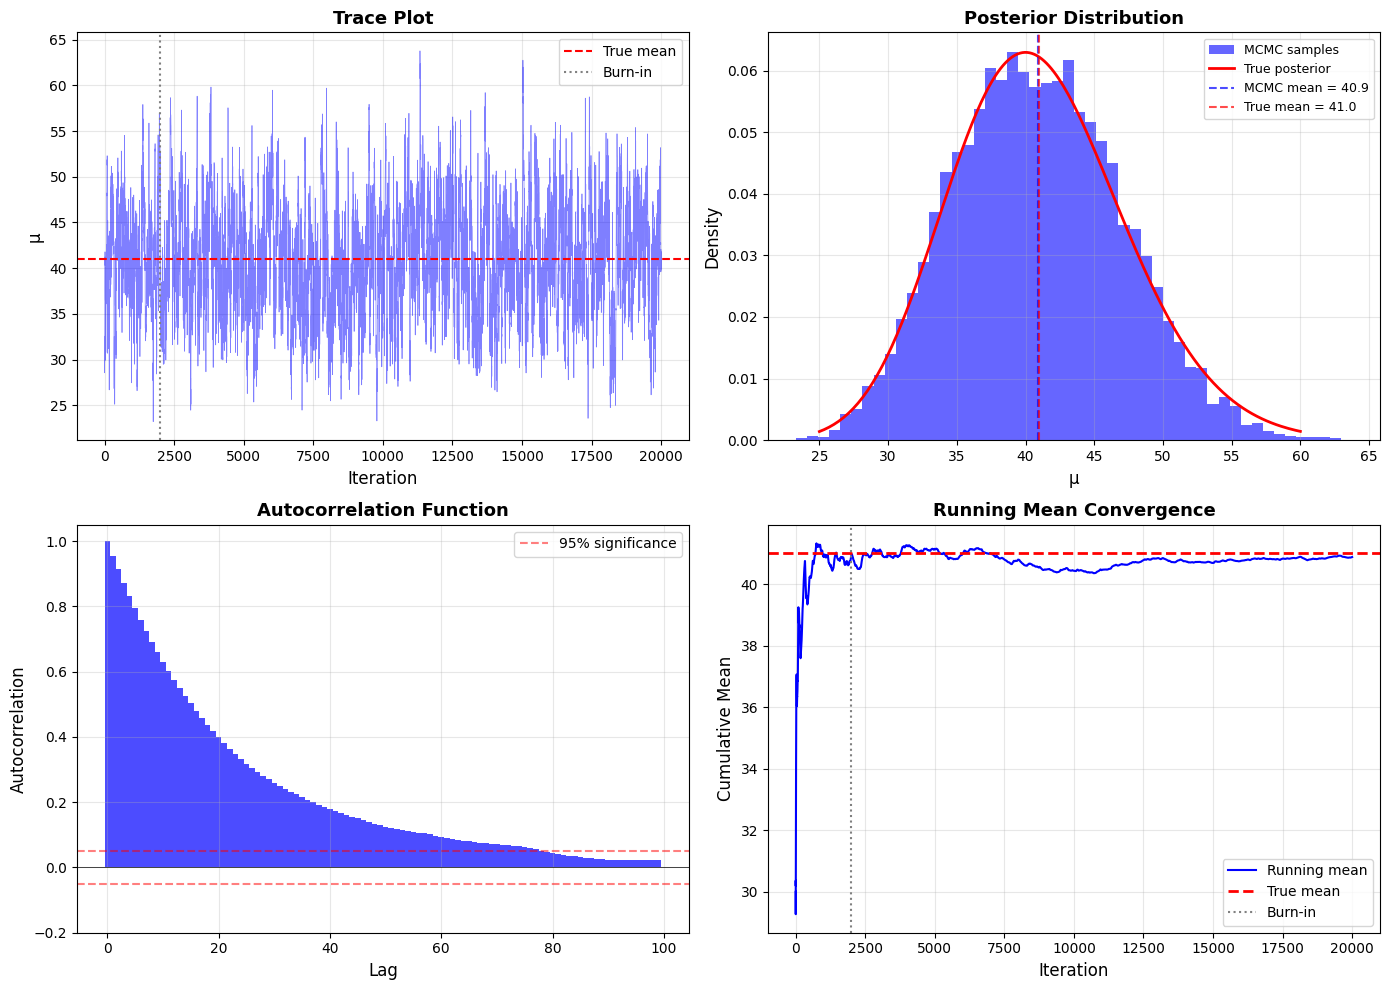

In [17]:
# Visualizations for convergence diagnostics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Trace plot
ax1 = axes[0, 0]
ax1.plot(mcmc_samples[:, 0], 'b-', alpha=0.5, linewidth=0.5)
ax1.axhline(posterior_mean, color='r', linestyle='--', label='True mean')
ax1.axvline(burn_in, color='gray', linestyle=':', label='Burn-in')
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('μ', fontsize=12)
ax1.set_title('Trace Plot', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Histogram vs true posterior
ax2 = axes[0, 1]
ax2.hist(mcmc_samples_burned, bins=50, density=True, alpha=0.6, color='blue', label='MCMC samples')
mu_plot = np.linspace(25, 60, 200)
ax2.plot(mu_plot, posterior.pdf(mu_plot), 'r-', linewidth=2, label='True posterior')
ax2.axvline(mcmc_mean, color='blue', linestyle='--', alpha=0.7, label=f'MCMC mean = {mcmc_mean:.1f}')
ax2.axvline(posterior_mean, color='red', linestyle='--', alpha=0.7, label=f'True mean = {posterior_mean:.1f}')
ax2.set_xlabel('μ', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Posterior Distribution', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# 3. Autocorrelation function
ax3 = axes[1, 0]
max_lag = 100
acf = np.correlate(mcmc_samples_burned - mcmc_mean, 
                   mcmc_samples_burned - mcmc_mean, mode='full')
acf = acf[len(acf)//2:] / acf[len(acf)//2]  # Normalize
lags = np.arange(max_lag)
ax3.bar(lags, acf[:max_lag], width=1.0, alpha=0.7, color='blue')
ax3.axhline(0, color='black', linewidth=0.5)
ax3.axhline(0.05, color='red', linestyle='--', alpha=0.5, label='95% significance')
ax3.axhline(-0.05, color='red', linestyle='--', alpha=0.5)
ax3.set_xlabel('Lag', fontsize=12)
ax3.set_ylabel('Autocorrelation', fontsize=12)
ax3.set_title('Autocorrelation Function', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim(-0.2, 1.05)

# 4. Running mean
ax4 = axes[1, 1]
running_mean = np.cumsum(mcmc_samples[:, 0]) / np.arange(1, len(mcmc_samples) + 1)
ax4.plot(running_mean, 'b-', linewidth=1.5, label='Running mean')
ax4.axhline(posterior_mean, color='r', linestyle='--', linewidth=2, label='True mean')
ax4.axvline(burn_in, color='gray', linestyle=':', label='Burn-in')
ax4.set_xlabel('Iteration', fontsize=12)
ax4.set_ylabel('Cumulative Mean', fontsize=12)
ax4.set_title('Running Mean Convergence', fontsize=13, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Part 4: Advantages of Hamiltonian Monte Carlo (HMC) / NUTS

**Hamiltonian Monte Carlo** uses gradient information to explore the parameter space more efficiently.

**Two key advantages over random-walk Metropolis:**

#### 1. **Much Lower Autocorrelation**

- **Random-walk MH**: Proposes small random steps, leading to highly correlated samples
  - Explores space slowly
  - High autocorrelation means need many more samples
  - Effective sample size is much smaller than actual sample size

- **HMC**: Uses gradient information to make large, directed moves through parameter space
  - Follows "momentum" to traverse typical set efficiently
  - Samples are much less correlated
  - Can explore in 10-100 steps what MH might take thousands of steps

**Result**: HMC typically achieves ESS that is 10-100× larger for the same computational cost

#### 2. **Better Scaling to High Dimensions**

- **Random-walk MH**: 
  - Acceptance rate decreases exponentially with dimension
  - Step size must decrease as $\propto 1/\sqrt{D}$ to maintain reasonable acceptance
  - Becomes impractical for $D > 10-20$ parameters

- **HMC**:
  - Uses gradient to "know where to go"
  - Acceptance rate remains high even in high dimensions
  - Scales to hundreds or thousands of parameters
  - Essential for modern problems (e.g., detector systematics with 100+ nuisance parameters)

**NUTS (No-U-Turn Sampler)**: An extension of HMC that automatically tunes the trajectory length, making it even more robust and user-friendly. Used in Stan and PyMC3.

**Trade-off**: HMC requires computing gradients of the log posterior, which can be computationally expensive. However, automatic differentiation tools make this practical.

In [18]:
# Demonstrate the difference in autocorrelation
# Compare our random-walk MH with a more efficient sampler

# Compute integrated autocorrelation time
def integrated_autocorr_time(samples, max_lag=None):
    """Estimate integrated autocorrelation time"""
    n = len(samples)
    if max_lag is None:
        max_lag = n // 10
    
    mean = np.mean(samples)
    var = np.var(samples)
    
    autocorr = np.zeros(max_lag)
    for lag in range(max_lag):
        autocorr[lag] = np.mean((samples[:-lag or None] - mean) * (samples[lag:] - mean)) / var
    
    # Integrated autocorrelation time
    tau = 1 + 2 * np.sum(autocorr[1:])
    return tau

tau_mh = integrated_autocorr_time(mcmc_samples_burned)
ess_mh = len(mcmc_samples_burned) / tau_mh

print(f"\nMetropolis-Hastings Performance:")
print(f"  Total samples (after burn-in): {len(mcmc_samples_burned)}")
print(f"  Integrated autocorrelation time: τ = {tau_mh:.1f}")
print(f"  Effective sample size: ESS = {ess_mh:.0f}")
print(f"  Efficiency: {ess_mh/len(mcmc_samples_burned)*100:.1f}%")

print(f"\nWith HMC/NUTS, you could expect:")
print(f"  τ ~ 1-5 (vs {tau_mh:.1f} for MH)")
print(f"  ESS ~ 3000-18000 (vs {ess_mh:.0f} for MH)")
print(f"  10-100× improvement in effective samples per iteration")


Metropolis-Hastings Performance:
  Total samples (after burn-in): 18000
  Integrated autocorrelation time: τ = 63.0
  Effective sample size: ESS = 286
  Efficiency: 1.6%

With HMC/NUTS, you could expect:
  τ ~ 1-5 (vs 63.0 for MH)
  ESS ~ 3000-18000 (vs 286 for MH)
  10-100× improvement in effective samples per iteration


---